In [71]:
import pandas as pd

In [72]:
df = pd.read_csv("../data/sales.csv")

In [73]:
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


In [74]:
df.shape

(1000, 17)

In [75]:
df.columns

Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Sales', 'Date',
       'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income',
       'Rating'],
      dtype='str')

In [76]:
df.isnull().sum()

Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Sales                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64

In [77]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   str    
 1   Branch                   1000 non-null   str    
 2   City                     1000 non-null   str    
 3   Customer type            1000 non-null   str    
 4   Gender                   1000 non-null   str    
 5   Product line             1000 non-null   str    
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Sales                    1000 non-null   float64
 10  Date                     1000 non-null   str    
 11  Time                     1000 non-null   str    
 12  Payment                  1000 non-null   str    
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  1000 non-nu

In [78]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
995    False
996    False
997    False
998    False
999    False
Length: 1000, dtype: bool

In [79]:
df.nunique()

Invoice ID                 1000
Branch                        3
City                          3
Customer type                 2
Gender                        2
Product line                  6
Unit price                  943
Quantity                     10
Tax 5%                      990
Sales                       990
Date                         89
Time                        506
Payment                       3
cogs                        990
gross margin percentage       1
gross income                990
Rating                       61
dtype: int64

In [80]:
df.describe()

,Unit price,Quantity,Tax 5%,Sales,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,0.000000,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905,49.650000,10.00000


In [81]:
df["Sales"].describe()

count    1000.000000
mean      322.966749
std       245.885335
min        10.678500
25%       124.422375
50%       253.848000
75%       471.350250
max      1042.650000
Name: Sales, dtype: float64

In [82]:
import matplotlib.pyplot as plt

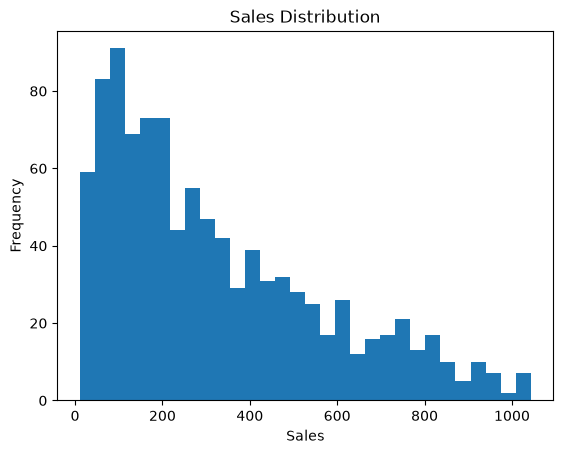

In [83]:
plt.hist(df["Sales"], bins=30)
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.title("Sales Distribution")
plt.show()

In [84]:
df.groupby("Product line")["Sales"].sum()

Product line
Electronic accessories    54337.5315
Fashion accessories       54305.8950
Food and beverages        56144.8440
Health and beauty         49193.7390
Home and lifestyle        53861.9130
Sports and travel         55122.8265
Name: Sales, dtype: float64

In [85]:
df.groupby("Branch")["Sales"].sum()

Branch
Alex     106200.3705
Cairo    106197.6720
Giza     110568.7065
Name: Sales, dtype: float64

In [86]:
df[["Quantity", "Sales"]].corr()

,Quantity,Sales
Quantity,1.00000,0.70551
Sales,0.70551,1.00000


In [87]:
df[["Unit price", "Sales"]].corr()

,Unit price,Sales
Unit price,1.000000,0.633962
Sales,0.633962,1.000000


In [88]:
df["Date"].head()

0     1/5/2019
1     3/8/2019
2     3/3/2019
3    1/27/2019
4     2/8/2019
Name: Date, dtype: str

In [89]:
df["Date"] = pd.to_datetime(df["Date"])

In [90]:
df["Month"] = df["Date"].dt.month

In [91]:
df["Year"] = df["Date"].dt.year

In [92]:
df["DayOfWeek"] = df["Date"].dt.dayofweek

In [93]:
df.groupby("Month")["Sales"].sum()

Month
1    116291.868
2     97219.374
3    109455.507
Name: Sales, dtype: float64

In [94]:
df.groupby("DayOfWeek")["Sales"].sum()

DayOfWeek
0    37899.0780
1    51482.2455
2    43731.1350
3    45349.2480
4    43926.3405
5    56120.8095
6    44457.8925
Name: Sales, dtype: float64

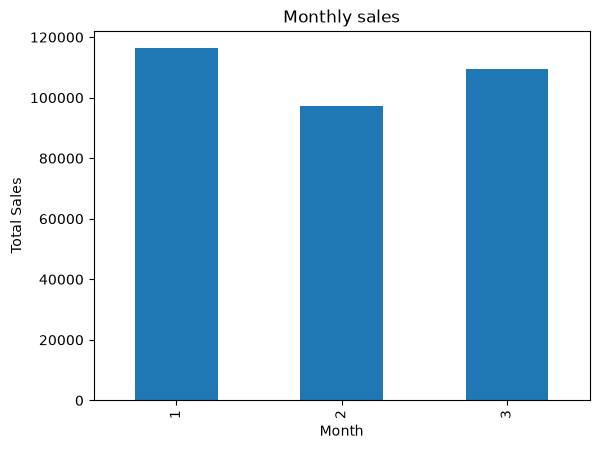

In [95]:
df.groupby("Month")["Sales"].sum().plot(kind="bar")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.title("Monthly sales")
plt.show()

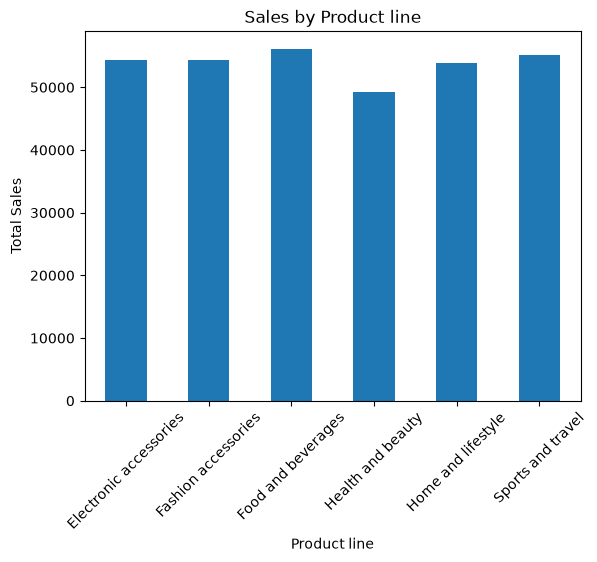

In [96]:
df.groupby("Product line")["Sales"].sum().plot(kind="bar")
plt.xlabel("Product line")
plt.ylabel("Total Sales")
plt.title("Sales by Product line")
plt.xticks(rotation=45)
plt.show()

In [97]:
df.groupby("Gender")["Sales"].sum()

Gender
Female    194671.8375
Male      128294.9115
Name: Sales, dtype: float64

In [98]:
df.groupby("Customer type")["Sales"].sum()

Customer type
Member    189694.764
Normal    133271.985
Name: Sales, dtype: float64

In [99]:
df.groupby("Payment")["Sales"].sum()

Payment
Cash           112206.570
Credit card    100767.072
Ewallet        109993.107
Name: Sales, dtype: float64

In [100]:
df.groupby("City")["Sales"].sum()

City
Mandalay     106197.6720
Naypyitaw    110568.7065
Yangon       106200.3705
Name: Sales, dtype: float64

In [101]:
df[["Rating", "Sales"]].corr()

,Rating,Sales
Rating,1.000000,-0.036442
Sales,-0.036442,1.000000


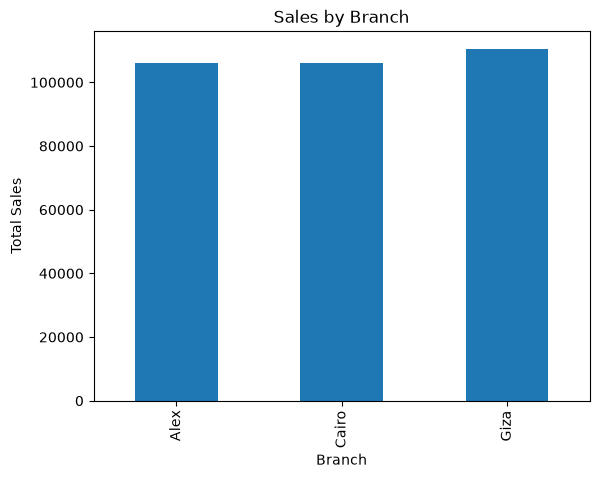

In [102]:
df.groupby("Branch")["Sales"].sum().plot(kind="bar")
plt.xlabel("Branch")
plt.ylabel("Total Sales")
plt.title("Sales by Branch")
plt.show()

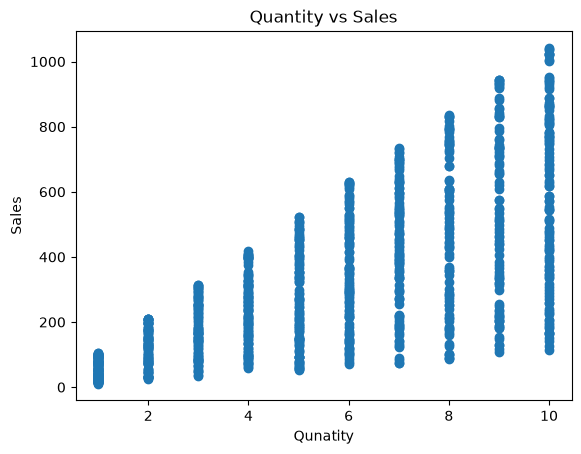

In [103]:
plt.scatter(df["Quantity"], df["Sales"])
plt.xlabel("Qunatity")
plt.ylabel("Sales")
plt.title("Quantity vs Sales")
plt.show()

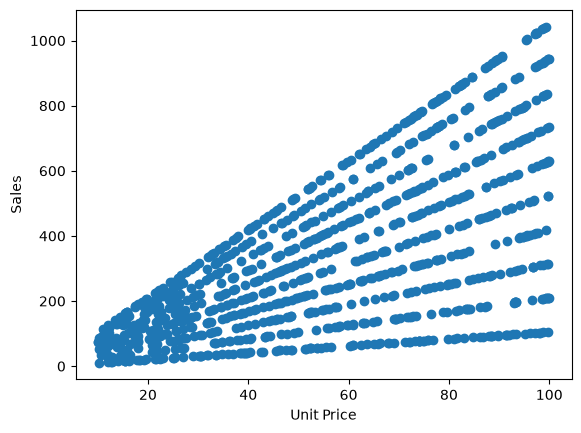

In [104]:
plt.scatter(df["Unit price"], df["Sales"])
plt.xlabel("Unit Price")
plt.ylabel("Sales")
plt.show()

In [105]:
df.duplicated().sum()

np.int64(0)

In [106]:
df["Product line"].unique()

<ArrowStringArray>
[     'Health and beauty', 'Electronic accessories',     'Home and lifestyle',
      'Sports and travel',     'Food and beverages',    'Fashion accessories']
Length: 6, dtype: str

In [107]:
df["Payment"].unique()

<ArrowStringArray>
['Ewallet', 'Cash', 'Credit card']
Length: 3, dtype: str

In [108]:
df["Customer type"].unique()

<ArrowStringArray>
['Member', 'Normal']
Length: 2, dtype: str

In [109]:
df["Gender"].unique()

<ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str

In [110]:
df["Branch"].unique()

<ArrowStringArray>
['Alex', 'Giza', 'Cairo']
Length: 3, dtype: str

In [111]:
df["City"].unique()

<ArrowStringArray>
['Yangon', 'Naypyitaw', 'Mandalay']
Length: 3, dtype: str

In [112]:
df["Sales"].isnull().sum()

np.int64(0)

In [113]:
df.columns

Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Sales', 'Date',
       'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income',
       'Rating', 'Month', 'Year', 'DayOfWeek'],
      dtype='str')

In [114]:
X = df.drop("Sales", axis=1)
y = df["Sales"]

In [115]:
X.shape, y.shape

((1000, 19), (1000,))

In [116]:
X.dtypes

Invoice ID                            str
Branch                                str
City                                  str
Customer type                         str
Gender                                str
Product line                          str
Unit price                        float64
Quantity                            int64
Tax 5%                            float64
Date                       datetime64[us]
Time                                  str
Payment                               str
cogs                              float64
gross margin percentage           float64
gross income                      float64
Rating                            float64
Month                               int32
Year                                int32
DayOfWeek                           int32
dtype: object

In [117]:
X = X.drop("Invoice ID", axis=1)

In [118]:
X = X.drop("Date", axis=1)

In [119]:
X = X.drop("Time", axis=1)

In [120]:
X.columns

Index(['Branch', 'City', 'Customer type', 'Gender', 'Product line',
       'Unit price', 'Quantity', 'Tax 5%', 'Payment', 'cogs',
       'gross margin percentage', 'gross income', 'Rating', 'Month', 'Year',
       'DayOfWeek'],
      dtype='str')

In [121]:
X.isnull().sum()

Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
Month                      0
Year                       0
DayOfWeek                  0
dtype: int64

In [122]:
from sklearn.model_selection import train_test_split

In [123]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [124]:
from sklearn.preprocessing import OneHotEncoder

In [125]:
categorical_cols = X_train.select_dtypes(include="object").columns

C:\Users\pantv\AppData\Local\Temp\ipykernel_8360\3916943964.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include="object").columns


In [133]:
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

In [134]:
print("Encoder created successfully")

Encoder created successfully


In [135]:
encoder.fit(X_train[categorical_cols])

,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a SciPy sparse matrix/arrayin ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide <encoder_infrequent_categories>`.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide <encoder_infreque

In [136]:
X_train_encoded = encoder.transform(X_train[categorical_cols])

In [137]:
X_test_encoded = encoder.transform(X_test[categorical_cols])

In [138]:
X_train_encoded.shape

(800, 19)

In [139]:
numeric_cols = X_train.select_dtypes(exclude="object").columns

In [140]:
numeric_cols

Index(['Unit price', 'Quantity', 'Tax 5%', 'cogs', 'gross margin percentage',
       'gross income', 'Rating', 'Month', 'Year', 'DayOfWeek'],
      dtype='str')

In [141]:
X_train_numeric = X_train[numeric_cols]

In [142]:
X_test_numeric = X_test[numeric_cols]

In [145]:
import numpy as np

X_train_final = np.hstack([X_train_numeric, X_train_encoded])

In [148]:
X_test_final = np.hstack([X_test_numeric, X_test_encoded])

In [149]:
X_train_final.shape, X_test_final.shape

((800, 29), (200, 29))

In [150]:
from sklearn.ensemble import RandomForestRegressor

In [152]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

In [153]:
model.fit(X_train_final, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [154]:
y_pred = model.predict(X_test_final)

In [155]:
y_pred

array([522.24984  , 620.922225 , 408.5883375, 135.85194  ,  44.448495 ,
       622.5833775, 127.848735 , 733.3773825, 451.708425 , 138.63129  ,
       423.1015425, 463.2310725, 213.4089825, 252.6566175, 290.4804525,
       330.0668175, 587.0382525, 217.026915 , 758.1678825, 185.098515 ,
       417.2285775, 165.92373  , 128.9369025, 125.6180625, 247.2127875,
       195.5946825, 743.4208425,  31.069815 , 145.63668  ,  56.414295 ,
        75.58005  , 609.1719375,  96.14598  , 433.26297  , 193.9326375,
       175.01778  , 665.4617025, 198.352875 , 193.9616175, 193.61286  ,
       214.25922  , 922.7106525,  74.682195 , 181.0245675,  93.0284775,
       401.3261175, 222.971595 ,  69.0296775, 343.7285775, 280.917735 ,
       430.70496  , 101.9452875,  68.99025  , 270.081735 , 181.21299  ,
       494.32299  , 462.6640725,  60.8687625, 457.246125 , 223.023465 ,
       121.769025 ,  33.367425 ,  84.74319  , 942.570405 , 383.325495 ,
       510.5899575, 369.45678  , 760.075995 , 935.22198  , 117.7

In [156]:
from sklearn.metrics import mean_absolute_error

In [157]:
mae = mean_absolute_error(y_test, y_pred)

In [158]:
mae

0.7583743125000051

In [159]:
from sklearn.metrics import mean_squared_error
import numpy as np

In [160]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

In [161]:
rmse

np.float64(1.3405090061156875)

In [162]:
from sklearn.metrics import r2_score

In [163]:
r2 = r2_score(y_test, y_pred)

In [164]:
r2

0.9999723794675544

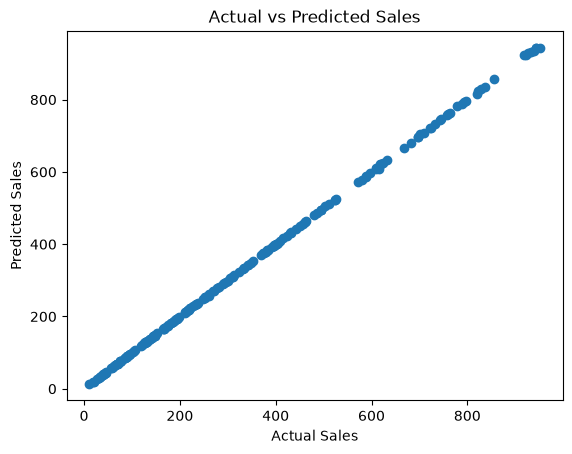

In [165]:
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

In [166]:
import joblib

In [167]:
joblib.dump(model, "../model/sales_model.pkl")

['../model/sales_model.pkl']

In [168]:
import os

os.path.exists("../model/sales_model.pkl")

True

In [169]:
joblib.dump(encoder, "../model/encoder.pkl")

['../model/encoder.pkl']

In [170]:
os.path.exists("../model/encoder.pkl")

True

In [171]:
joblib.dump(
    {
        "categorical_cols": list(categorical_cols),
        "numeric_cols": list(numeric_cols)
    },
    "../model/features.pkl"
)

['../model/features.pkl']

In [172]:
os.path.exists("../model/features.pkl")


True

In [173]:
print("Categorical columns:")
print(categorical_cols)

print("\nNumeric columns:")
print(numeric_cols)

Categorical columns:
Index(['Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Payment'], dtype='str')

Numeric columns:
Index(['Unit price', 'Quantity', 'Tax 5%', 'cogs', 'gross margin percentage',
       'gross income', 'Rating', 'Month', 'Year', 'DayOfWeek'],
      dtype='str')
